# Simulation validation: Simulation of the miRNA detection with the PUMA method

The goal of this notebook is to validate our simulator by reproducing, through simulation, the results about miRNA detection, within the Programmable Ultrasensitive Molecular Amplifier (PUMA) method.

The method of this detection protocol has been presented in 
Yannick Rondelez, Guillaume Ginès. 
*Programmable Ultrasensitive Molecular Amplifier for Digital and
Multiplex MicroRNA Quantification.* MicroRNA Detection and Target Identification, 2630, Springer
US, pp.89-102, 2023, Methods in Molecular Biology

Some experiments and concentrations are presented in
Antoine Masurier, Rémi Sieskind, Guillaume Ginès, Yannick Rondelez. *DNA circuit-based immunoassay for ultrasensitive protein pattern classification.* Analyst, 2024, 149 (20), pp.5052-5062.


We simulate here a system composed of two species:
- alpha 
- beta

and four templates:
- cT: beta to alpha
- dT: drain of alpha
- aT: alpha to alpha
- rT: reporter template of alpha

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

# Get the absolute path to the root directory
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)


from PEN_simulation import PEN_System
from strands import Signal, Drain, Template, Reporter, reverse_complement


# Saving figs
saving=True
if saving:
    os.makedirs("figures/detection", exist_ok=True)



def detection_system(
    temperature=45,
    leak=3e-8,
    BsmI_conc=400,
    NBI_conc=10,
    pol_conc=30,
    exo_conc=23,
    mir_conc=0,
    alpha_conc=0,
    cT_conc=0,
    dT_conc=0,
    aT_conc=0,
    rT_conc=0,
    leak_aT=None,
    leak_cT=None,
    ):

    system = PEN_System(temperature=temperature,
                        concentration_BsmI=BsmI_conc,
                        concentration_NBI=NBI_conc,
                        concentration_pol=pol_conc,
                        concentration_exo=exo_conc,
                        leak=leak)

    # Define the Triggers
    alpha=Signal(name="alpha", 
                 sequence="CATTCAGGATCG", 
                 concentration=alpha_conc,
                 protected=False, 
                 IsDrained=True, 
                 plus=0)
    alpha_p2m2=Signal(name="alpha", 
                      sequence="TTCAGGATCGCA", 
                      concentration=0, 
                      protected=False, 
                      IsDrained=True, 
                      plus=2,
                      minus=2)
    alpha_m2=Signal(name="alpha", 
                      sequence="TTCAGGATCG", 
                      concentration=0, 
                      protected=False, 
                      IsDrained=True, 
                      plus=0,
                      minus=2)
    mir=Signal(name="mir",
               sequence="AGGTTGGGATCGGTTGCAATGCT", # U replaced by T here, we consider the hybridization process is the same
               concentration=mir_conc, 
               protected=False, 
               IsDrained=True)
    system.add_signal(alpha)
    system.add_signal(mir)
    system.add_signal(alpha_p2m2)
    system.add_signal(alpha_m2)

    # Define the Templates
    aT = Template(name="aT", 
                  sequence="CGATCCTGAATGCGATCCTGAA", 
                  input=alpha, 
                  output=alpha, 
                  concentration=aT_conc, 
                  nick="BsmI", 
                  protected=True, 
                  irreversible=False, 
                  phosphorylated=True, 
                  leak=leak_aT)
    cT = Template(name="cT", 
                  sequence="TGCGATCCTGAAGTTTGACTCAAGCATTGCAACCGATCCCAACCT", 
                  input=mir, 
                  output=alpha_p2m2, 
                  concentration=cT_conc, 
                  nick="NBI", 
                  protected=True, 
                  irreversible=True, 
                  leak=leak_cT)
    system.add_template(aT)
    system.add_template(cT)

    # Define the dT template
    pT = Drain(name="pT", 
               input=alpha, 
               concentration=dT_conc, 
               sequence= "TTTTTCGATCCTGAATG", 
               protected=True)
    system.add_drain(pT)

    # Define the reporter template
    rT_output = Signal(name="rT_output", 
                       sequence="CATTCAGAAT", 
                       concentration=0, 
                       protected=False, 
                       IsDrained=False)
    system.add_signal(rT_output)
    rT_alpha = Reporter(name="rT_alpha", 
                        input=alpha, 
                        fluorophore="Atto633", 
                        quencher="BHQ1", 
                        sequence="ATTCAGAATGCGATCCTGAAT", 
                        concentration=rT_conc, 
                        reversible=True, 
                        output=rT_output)
    system.add_reporter(rT_alpha)

    
    return system


def peak_time(y,t):
    max = y.max()
    
    # dichotomy for finding time at half 
    a=0
    b=len(y)-1
    while b-a>1:
        c = (a+b)//2
        if y[c]<max/2:
            a=c
        else:
            b=c
    return (t[a] + t[b]) / 2

## 1) Tuning the drain concentration depending on the leak parameters

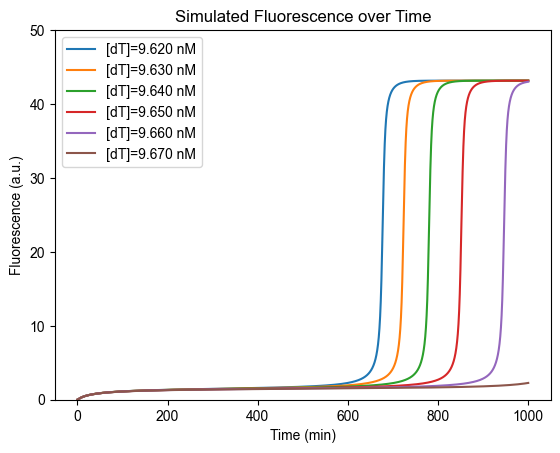

PEN System Summary
Temperature: 50 °C
Leak rate: 3e-08
Sodium concentration: 0.07 M
Magnesium concentration: 0.0125 M

--------------------------------------------------
Kinetic Rates Dictionary
--------------------------------------------------
alpha           <-> aT              (input) : k_on = 8.90e-01 nM⁻¹·min⁻¹, k_off = 5.58e+03 min⁻¹
alpha           <-> aT              (output) : k_on = 5.86e-01 nM⁻¹·min⁻¹, k_off = 5.93e+02 min⁻¹
alpha           <-> pT              : k_on = 5.86e-01 nM⁻¹·min⁻¹, k_off = 5.93e+02 min⁻¹
alpha           <-> rT_alpha        : k_on = 8.21e-01 nM⁻¹·min⁻¹, k_off = 2.36e+03 min⁻¹
mir             <-> cT              : k_on = 9.90e-01 nM⁻¹·min⁻¹, k_off = 2.50e-06 min⁻¹
alpha           <-> cT              : k_on = 8.68e-01 nM⁻¹·min⁻¹, k_off = 5.24e+01 min⁻¹
rT_output       <-> rT_alpha        : k_on = 8.42e-01 nM⁻¹·min⁻¹, k_off = 5.91e+06 min⁻¹
alpha           <-> rT_alpha        : k_on = 8.68e-01 nM⁻¹·min⁻¹, k_off = 5.24e+01 min⁻¹
alpha           <-> rT_al

In [2]:
t=np.linspace(0,1000,100001)

drain_conc_list=np.linspace(9.62,9.67,6)


# b_list=[0]

for drain_conc in drain_conc_list:
    system=detection_system(
                # Parameters to tune
                pol_conc=80, # Be careful, it's VENT here, not Bst
                leak_aT=6.3e-7, # Seems good
                leak_cT=6.3e-7, # Seems good

                # Parameters from Masurier24
                temperature=50,

                exo_conc=23,
                BsmI_conc=300,
                NBI_conc=10,
                
                aT_conc=50,
                dT_conc=drain_conc, 
                cT_conc=0.5,
                rT_conc=50,

                mir_conc=0
            )

    y=system.solve_system(t)
    fluo=system.fluorescence_list(y, "rT_alpha")

    plt.plot(t,fluo, label=f"[dT]={drain_conc:.3f} nM")

# system.print(enzymes_kinetic=True, detailed_kinetics=True)
plt.xlabel("Time (min)")
plt.ylabel("Fluorescence (a.u.)")
plt.title("Simulated Fluorescence over Time")
plt.ylim(0,50)
plt.legend()
plt.show()

system.print(detailed_kinetics=True)

## 2) Computing the leak computation

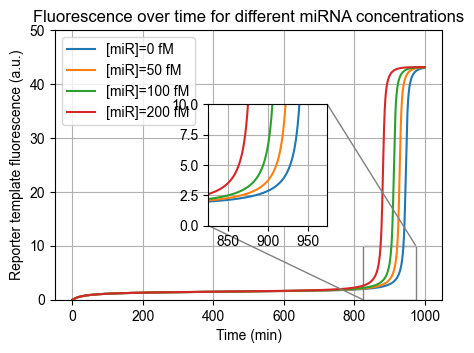

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

t = np.linspace(0, 1000, 10001)
mir_concentration_list = [0, 5e-5,1e-4,2e-4]

fig, ax = plt.subplots(figsize=(5,3.5))
axins = zoomed_inset_axes(ax, 
                          zoom=2.25,
                          loc='center',
                          bbox_to_anchor=(0.55,0.5),
                           bbox_transform=ax.transAxes,
                          )


for mir_concentration in mir_concentration_list:
    system = detection_system(
        pol_conc=80,
        leak_aT=6.3e-7,
        leak_cT=6.3e-7,
        temperature=50,
        exo_conc=23,
        BsmI_conc=300,
        NBI_conc=10,
        aT_conc=50,
        dT_conc=9.66,
        cT_conc=0.5,
        rT_conc=50,
        mir_conc=mir_concentration
    )
    y = system.solve_system(t)
    fluo = system.fluorescence_list(y, "rT_alpha")
    ax.plot(t, fluo, label=f"[miR]={int(mir_concentration * 1e6)} fM")
    axins.plot(t, fluo, label=f"[miR]={int(mir_concentration * 1e6)} fM")
    
axins.set_xlim(825, 975)
axins.set_ylim(0, 10)
axins.grid()


ax.set_xlabel("Time (min)")
ax.set_ylabel("Reporter template fluorescence (a.u.)")
ax.set_title("Fluorescence over time for different miRNA concentrations")
ax.set_ylim(0, 50)
ax.legend()
ax.grid()

mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="0.5")

if saving:
    plt.savefig("figures/detection/PUMA.pdf")
plt.show()


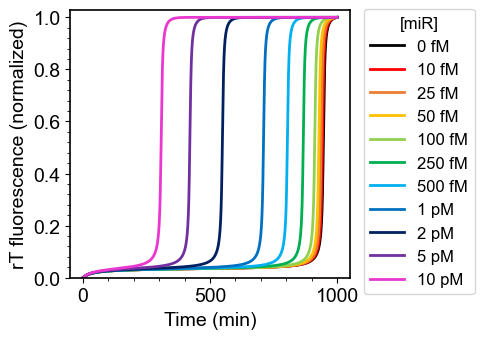

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
from matplotlib.ticker import AutoMinorLocator

t = np.linspace(0, 1000, 10001)
mir_concentration_list = [ 10e-3, 5e-3, 2.5e-3, 1e-3, 500e-6, 250e-6, 100e-6, 50e-6, 25e-6, 10e-6, 0]

fig, ax = plt.subplots(figsize=(5,3.5))

colors=["#e937d0",
        "#7030a0",
        "#002060",
        "#0070c0",
        "#00b0f0",
        "#00b050",
        "#92d050",
        "#ffc000",
        "#ed7d31",
        "#ff0000",
        "#000000"]

for mir_concentration, color in zip(mir_concentration_list[::-1], colors[::-1]):
    system = detection_system(
        pol_conc=80,
        leak_aT=6.3e-7,
        leak_cT=6.3e-7,
        temperature=50,
        exo_conc=23,
        BsmI_conc=300,
        NBI_conc=10,
        aT_conc=50,
        dT_conc=9.66,
        cT_conc=0.5,
        rT_conc=50,
        mir_conc=mir_concentration
    )
    y = system.solve_system(t)
    fluo = system.fluorescence_list(y, "rT_alpha")
    if mir_concentration >= 1e-3:
        label=f"{int(mir_concentration * 1e3)} pM"
    else:
        label=f"{int(mir_concentration * 1e6)} fM"
    ax.plot(t, fluo/fluo.max(), label=label, linewidth=2, color=color)
    
axins.set_xlim(825, 975)
axins.set_ylim(0, 10)
axins.grid()


ax.set_xlabel("Time (min)", fontsize=14)
ax.set_ylabel("rT fluorescence (normalized)", fontsize=14)
ax.set_ylim(0, 1.03)

# mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="0.5")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

# Move legend to the right of the plot (outside)
ax.legend(
    bbox_to_anchor=(1.05, 1.002),  # Position the legend outside the plot
    loc='upper left',          # Align the legend's upper left corner with the anchor
    borderaxespad=0.,           # Padding between the legend and the axes
    fontsize=12,
    title="[miR]",
    title_fontsize=12
)

ax.tick_params(axis='both', which='major', labelsize=14)

# Set major and minor ticks
ax.xaxis.set_minor_locator(AutoMinorLocator(5))  # Add 5 minor ticks between major ticks on the x-axis
ax.yaxis.set_minor_locator(AutoMinorLocator(5))  # Add 5 minor ticks between major ticks on the y-axis

plt.tight_layout()
if saving:
    plt.savefig("figures/detection/PUMA.pdf")
plt.show()


The limit of detection if here of ~100 fM. We are close of the LoD of 1 fM found in Ginès2020, in figure 2; and of 136 fM in Masurier2024, in figure 1.  

We can further improve our LoD by tuning our leak rate and drain concentration.

## Conclusion

Very promising, as we can work with very small concentrations. Moreover, same order than in the experiments, even without really knowing the leak rates.